In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Literal

In [14]:
# Reading the data
data = pd.read_csv('heart.csv')

data[:5]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [15]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

This shows that none of them have missing/null values

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [17]:
# train test split. 

x = np.array(data.iloc[:, :-1], dtype=np.float32)
y = np.array(data.iloc[:, -1], dtype=np.float32)

idx = int(0.8*len(x))

train_x, train_y = x[:idx][:], y[:idx]
test_x, test_y = x[idx:][:], y[idx:]

In [18]:
# Z-Score normalization. 

def std_dev(arr: np.ndarray):
    return np.sqrt(np.sum(np.square(arr))/len(arr) - np.square(np.mean(arr)))

def zscore(arr: np.ndarray):
    return (arr - np.mean(arr))/std_dev(arr)


In [19]:
# Normalizing features.

n_features = [0, 3, 4, 7, 9]

for i in n_features:
    train_x[:, i] = zscore(train_x[:, i])

for i in n_features:
    test_x[:, i] = zscore(test_x[:, i])

In [20]:
# defining functions and their derivatives (for backpropagation)

def sigmoid(x: np.ndarray):
    return 1/(1 + np.exp(-x))

def sigmoid_derivative(x: np.ndarray):
    return sigmoid(x) * (1 - sigmoid(x))

def relu(x: np.ndarray):
    return np.maximum(0, x)

def relu_derivative(x: np.ndarray):
    return (x > 0).astype(float)

def binary_cross_entropy(y_true, y_pred):
    # add small epsilon to avoid log(0)
    epsilon = 1e-7
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

# Techniques used in propagation.

## Initializing the weight matrix from one layer to other and using matrix multiplication. (forward)

Suppose we have a network with the input layer having size $(13, 1)$ and the next layer having $(8, 1)$ I initialize the weight matrix between these layers in the shape $(8, 13)$, and a bias matrix of shape $(8, 1)$. So, if we matrix multiply the input and the weight matrix,

$$
    (8, 13) * (13, 1) = (8, 1)
$$

Therefore making the following dimensionally correct and valid. 

$$
    z = w\cdot x + b
$$

## Finding delta and iterating over layers. (backward)

Consider we have the loss function as, 
$$
L = \text{BCE}(y, \hat{y})
$$

The gradient of the first weight of the output layer can be written as, 
$$
\frac{ \partial L }{ \partial w_{11}^{(3)} } = \frac{ \partial L }{ \partial \hat{y_{1}} } \cdot \frac{ \partial \hat{y_{1}} }{ \partial z_{1}^{(3)} } \cdot \frac{ \partial z_{1}^{(3)} }{ \partial w_{11}^{(3)} }    
$$
Now we define $\delta_{1} ^{(3)}$ as, 
$$
\delta_{1} ^{(3)} = \frac{ \partial L }{ \partial \hat{y_{1}} } \cdot \frac{ \partial \hat{y_{1}} }{ \partial z_{1}^{(3)} }
$$
We know that, 
$$
\frac{ \partial z_{1}^{(3)} }{ \partial w_{11}^{(3)} } = h_{1}^{(2)}
$$
where $h_{1}^{(2)}$ is the value of first neuron of the previous layer. Now, for each output neuron and for each neuron in its previous layer, we can write. 

$$
\delta^{(3)} = \begin{bmatrix}

\delta_1 ^{(3)} \\

\\

\delta_2 ^{(3)} \\

\\

\vdots\\

\\

\delta_n ^{(3)} \\

\end{bmatrix} 
$$
and
$$
h^{(2)} = \begin{bmatrix}

h_1 ^{(3)} & h_2 ^{(3)} & \cdots & h_m ^{(3)} \\

\end{bmatrix}
$$

We can get the gradient matrix that is of the same shape as that of the weight matrix by just matrix multiplying $\delta^{(3)}$ and $h^{(3)}$ and do the gradient descent calculation.
$$
w^{(3)} = w^{(3)} - \lambda \frac{ \partial L }{ \partial w^{(3)} } 
$$

We get the values of delta for the backward layers by, 
$$
\delta^{(L)}_j = \mathbf{A} ^{\prime} (z_j ^{(L)}) \cdot \sum_{i=1}^{n} \delta_i ^{(L+1)} \cdot w_{ij}^{(L)}
$$


In [21]:
# Creating the network.

class FeedForwardNetwork:
    def __init__(self, inputs, hidden_structure: list, n_outputs, labels, activation: Literal["sigmoid", "relu"], epochs = 69) -> None:

        self.inputs = inputs 
        self.hidden = []
        self.weights = []
        self.biases = []
        self.learning_rate = 0.01
        self.epochs = epochs
        
        # getting the hidden layers in a single list
        for i in range(len(hidden_structure)):
            self.hidden.append(np.zeros(hidden_structure[i], dtype=np.float32))
        
        # setting the network structure, example [13, 8, 4, 1]
        self.network_structure = [len(self.inputs[0])]
        for i in hidden_structure: self.network_structure.append(i)
        self.network_structure.append(n_outputs)

        # initializing random weights and biases, with the sizes like (8, 13), (4, 8) to ease up the matrix multiplication and addition of biases.
        for i in range(len(self.network_structure)):
            if self.network_structure[i] != self.network_structure[-1]:
                self.weights.append(np.random.rand(self.network_structure[i+1], self.network_structure[i]))
                self.biases.append(np.zeros((self.network_structure[i+1], 1), dtype=np.float32))

        # initializing the output layer.
        self.outputs = np.zeros(n_outputs, dtype=np.float32)
        self.layers = self.hidden + [self.outputs]
        self.labels = labels

        # assigning the sigmoid and relu activation functions.
        if activation == "sigmoid":
            self.activation = sigmoid
            self.activation_derivative = sigmoid_derivative
        elif activation == "relu":
            self.activation = relu
            self.activation_derivative = relu_derivative

    def forward(self, x):
        
        x = x.reshape(len(x), 1)     # doing this because x.shape usually will be like (len(x),) which is not good for matrix multiplication.
        network_layers = [x] + self.layers
        self.z_values = [x]

        # forward propagating through all layers using for loop. 
        for i in range(len(self.network_structure)-1):

            weight_matrix = self.weights[i]
            bias_matrix = self.biases[i]

            z = weight_matrix @ network_layers[i] + bias_matrix
            network_layers[i+1] = self.activation(z)
            
            self.z_values.append(z)

        self.layers = network_layers[1:]  # to update the value of the layers. 


    def backward(self, idx, x):
        
        if self.activation == sigmoid:
            
            x = x.reshape(len(x), 1)
            network_layers = [x] + self.layers
            delta = np.array(self.layers[-1] - self.labels[idx], dtype=np.float32) # because the delta term will just be yhat - y, if used sigmoid for activation and BCE for loss function. 

            for i in range(-1, -1*len(network_layers), -1):
                
                self.weights[i] -= self.learning_rate* (delta @ network_layers[i-1].T)
                self.biases[i] -= self.learning_rate * delta

                delta = self.activation_derivative(self.z_values[i-1])*np.dot(delta.T, self.weights[i]).T
                
    def train_model(self):
        self.train_losses = []

        for epoch in range(1, self.epochs+1):
            
            epoch_correct = 0
            epoch_loss = 0

            for idx in range(len(self.inputs)):
                self.forward(self.inputs[idx])
                self.backward(idx, self.inputs[idx])
                
                y_pred = self.layers[-1][0][0]

                pred_label = 1 if y_pred >= 0.5 else 0 

                epoch_correct += int(pred_label == self.labels[idx])

                loss = binary_cross_entropy(self.labels[idx], y_pred)
                epoch_loss += loss

            avg_loss = epoch_loss / len(self.inputs)
            self.train_losses.append(avg_loss)               

            
            if epoch%10 == 0: print(f"Epoch: {epoch}/{self.epochs}, Training accuracy: {100*epoch_correct/len(self.inputs)}")

    def test_model(self, test_inputs, test_labels):
        
        predictions = []
        
        # get predictions
        for idx in range(len(test_inputs)):
            self.forward(test_inputs[idx])
            y_pred = self.layers[-1][0, 0]
            pred_label = 1 if y_pred >= 0.5 else 0
            predictions.append(pred_label)
        
        # convert to numpy arrays for easier calculation
        predictions = np.array(predictions)
        test_labels = np.array(test_labels)
        
        # calculate confusion matrix
        tp = np.sum((predictions == 1) & (test_labels == 1))  # true positives
        tn = np.sum((predictions == 0) & (test_labels == 0))  # true negatives
        fp = np.sum((predictions == 1) & (test_labels == 0))  # false positives
        fn = np.sum((predictions == 0) & (test_labels == 1))  # false negatives
        
        # calculate metrics
        accuracy = (tp + tn) / len(test_labels)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        # print results
        print(f"\n=== Test Results ===")
        print(f"Accuracy: {100*accuracy:.2f}%")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1_score:.4f}")
        print(f"\nConfusion Matrix:")
        print(f"TN: {tn}  FP: {fp}")
        print(f"FN: {fn}  TP: {tp}")


    def plot_loss_curve(self):
        plt.figure(figsize=(10, 6))
        plt.plot(self.train_losses, linewidth=2, color='blue')
        plt.xlabel('Epoch', fontsize=12)
        plt.ylabel('Binary Cross-Entropy Loss', fontsize=12)
        plt.title('Training Loss Over Time', fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.show()

In [22]:
network = FeedForwardNetwork(inputs=train_x, hidden_structure=[8, 5], n_outputs=1, labels=train_y, activation="sigmoid", epochs=10000)

network.train_model()

Epoch: 10/10000, Training accuracy: 49.8780487804878
Epoch: 20/10000, Training accuracy: 49.63414634146341
Epoch: 30/10000, Training accuracy: 49.75609756097561
Epoch: 40/10000, Training accuracy: 49.63414634146341
Epoch: 50/10000, Training accuracy: 51.829268292682926
Epoch: 60/10000, Training accuracy: 62.5609756097561
Epoch: 70/10000, Training accuracy: 84.51219512195122
Epoch: 80/10000, Training accuracy: 87.5609756097561
Epoch: 90/10000, Training accuracy: 88.29268292682927
Epoch: 100/10000, Training accuracy: 90.0
Epoch: 110/10000, Training accuracy: 90.2439024390244
Epoch: 120/10000, Training accuracy: 90.73170731707317
Epoch: 130/10000, Training accuracy: 91.09756097560975
Epoch: 140/10000, Training accuracy: 91.58536585365853
Epoch: 150/10000, Training accuracy: 92.1951219512195
Epoch: 160/10000, Training accuracy: 92.3170731707317
Epoch: 170/10000, Training accuracy: 92.6829268292683
Epoch: 180/10000, Training accuracy: 92.92682926829268
Epoch: 190/10000, Training accuracy: 9

In [23]:
network.test_model(test_x, test_y)


=== Test Results ===
Accuracy: 97.56%
Precision: 0.9700
Recall: 0.9798
F1 Score: 0.9749

Confusion Matrix:
TN: 103  FP: 3
FN: 2  TP: 97


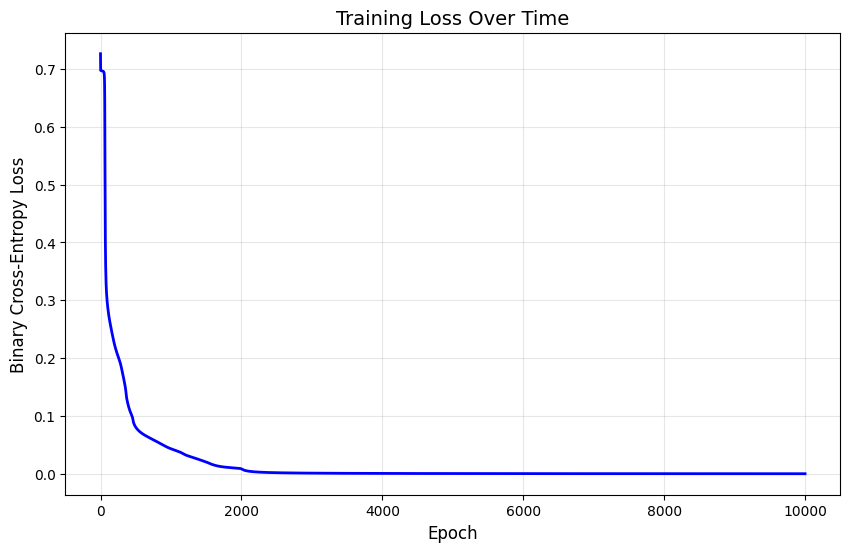

In [24]:
network.plot_loss_curve()